# PHASE 1 — DATA CLEANING

## Project Objective

**Business question:** QuickBasket has meaningful sales volume, but is it growing profitably? This project uses transaction-level data to identify where revenue is created, where margin is lost, and which operational or commercial levers management should review.

**Portfolio scope:** The core analysis focuses on data cleaning, business performance, profitability, product/category performance, and delivery experience. RFM is retained as an optional customer-analytics extension.

### Tools used

- Python
- Pandas
- NumPy
- Matplotlib

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
marketing_spend = pd.read_csv("marketing_spend.csv")


In [ ]:
customers.head()

,customer_id,signup_date,city,age,gender,acquisition_channel,is_prime_member
0,C100000,28-06-2025,Delhi,35.0,F,Instagram Ads,0
1,C100001,13-04-2025,Delhi,34.0,F,Instagram Ads,0
2,C100002,01-06-2025,Mumbai,40.0,F,Instagram Ads,1
3,C100003,09-10-2024,Mumbai,39.0,Other,Google Ads,1
4,C100004,22-12-2025,Delhi,30.0,M,Organic,0


In [ ]:
orders.head()

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status
0,O709661,C102337,02-11-2025,Chennai,Wallet,26.4,4.5,25,Delivered
1,O716079,C103894,25-07-2025,Mumbai,UPI,29.3,4.0,15,Delivered
2,O700874,C100207,27-12-2025,Mumbai,COD,15.4,5.0,0,Delivered
3,O704581,C101109,04-04-2025,Delhi,UPI,25.8,4.0,10,Delivered
4,O707306,C101795,29-08-2025,Delhi,UPI,19.2,5.0,5,Delivered


STEP 2 — Check the shape of each dataset

In [ ]:
customers.shape

(6000, 7)

In [ ]:
products.shape

(139, 6)

In [ ]:
orders.shape

(25028, 9)

In [ ]:
order_items.shape

(101989, 4)

In [ ]:
marketing_spend.shape

(21930, 6)

STEP 3 — Check Data Types

In [ ]:
customers.dtypes

customer_id             object
signup_date             object
city                    object
age                    float64
gender                  object
acquisition_channel     object
is_prime_member          int64
dtype: object

In [ ]:
products.dtypes

product_id       object
product_name     object
category         object
sub_category     object
mrp               int64
cost_price      float64
dtype: object

In [ ]:
orders.dtypes

order_id             object
customer_id          object
order_date           object
city                 object
payment_mode         object
delivery_minutes    float64
delivery_rating     float64
discount_pct          int64
order_status         object
dtype: object

In [ ]:
order_items.dtypes

order_id       object
product_id     object
quantity        int64
unit_price    float64
dtype: object

In [ ]:
marketing_spend.dtypes

date            object
channel         object
city            object
spend_inr      float64
impressions      int64
clicks           int64
dtype: object

STEP 4 — Check Missing Values

In [ ]:
customers.isnull().sum()

customer_id              0
signup_date              0
city                     0
age                    301
gender                   0
acquisition_channel      0
is_prime_member          0
dtype: int64

In [ ]:
products.isnull().sum()

product_id      0
product_name    0
category        0
sub_category    0
mrp             0
cost_price      0
dtype: int64

In [ ]:
orders.isnull().sum()

order_id               0
customer_id            0
order_date             0
city                   0
payment_mode         276
delivery_minutes     502
delivery_rating     1699
discount_pct           0
order_status           0
dtype: int64

In [ ]:
order_items.isnull().sum()

order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64

In [ ]:
marketing_spend.isnull().sum()

date           0
channel        0
city           0
spend_inr      0
impressions    0
clicks         0
dtype: int64

STEP 5 — Check Duplicates

In [ ]:
customers.duplicated().sum()

np.int64(0)

In [ ]:
products.duplicated().sum()

np.int64(0)

In [ ]:
orders.duplicated().sum()

np.int64(292)

In [ ]:
order_items.duplicated().sum()

np.int64(804)

In [ ]:
marketing_spend.duplicated().sum()

np.int64(0)

STEP 6 — Investigate Duplicate Orders

In [ ]:
orders[orders.duplicated(keep=False)].sort_values("order_id").head(20)

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status
1606,O700089,C100025,28-03-2025,Pune,Wallet,16.1,5.0,10,Delivered
24041,O700089,C100025,28-03-2025,Pune,Wallet,16.1,5.0,10,Delivered
13456,O700111,C100029,25-09-2025,Pune,Wallet,23.3,4.0,25,Delivered
3926,O700111,C100029,25-09-2025,Pune,Wallet,23.3,4.0,25,Delivered
16860,O700184,C100040,27-11-2025,Delhi,UPI,13.0,5.0,20,Delivered
1878,O700184,C100040,27-11-2025,Delhi,UPI,13.0,5.0,20,Delivered
6758,O700196,C100041,19-09-2025,Mumbai,Card,7.4,5.0,10,Delivered
24430,O700196,C100041,19-09-2025,Mumbai,Card,7.4,5.0,10,Delivered
827,O700200,C100043,17-06-2024,Pune,UPI,15.2,5.0,10,Cancelled
15897,O700200,C100043,17-06-2024,Pune,UPI,15.2,5.0,10,Cancelled


In [ ]:
orders[orders.duplicated("order_id", keep = False)]["order_id"].nunique()

296

In [ ]:
orders[orders.duplicated("order_id", keep = False)].sort_values("order_id")

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status
24041,O700089,C100025,28-03-2025,Pune,Wallet,16.1,5.0,10,Delivered
1606,O700089,C100025,28-03-2025,Pune,Wallet,16.1,5.0,10,Delivered
13456,O700111,C100029,25-09-2025,Pune,Wallet,23.3,4.0,25,Delivered
3926,O700111,C100029,25-09-2025,Pune,Wallet,23.3,4.0,25,Delivered
16860,O700184,C100040,27-11-2025,Delhi,UPI,13.0,5.0,20,Delivered
...,...,...,...,...,...,...,...,...,...
24358,O724411,C105924,24-11-2025,Delhi,UPI,25.0,5.0,20,Cancelled
16014,O724515,C105952,25-02-2025,Mumbai,Wallet,17.8,5.0,10,Delivered
12548,O724515,C105952,25-02-2025,Mumbai,Wallet,17.8,5.0,10,Delivered
24661,O724552,C105959,01-10-2024,Pune,UPI,16.8,4.0,30,Delivered


In [ ]:
dup_info = orders[orders.duplicated("order_id", keep = False)]
conflicting_ids = (dup_info.groupby("order_id").nunique().max(axis = 1))
conflicting_ids[conflicting_ids>1]

order_id
O706248    2
O715278    2
O718962    2
O719111    2
dtype: int64

In [ ]:
orders[
    orders["order_id"].isin (conflicting_ids[conflicting_ids>1].index)
    ].sort_values("order_id")

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status
3048,O706248,C101525,08-05-2025,Mumbai,UPI,22.5,4.0,0,Delivered
14962,O706248,C101525,08-05-2025,Mumbai,UPI,802.2,4.0,0,Delivered
1741,O715278,C103707,13-08-2025,Mumbai,UPI,422.4,3.5,20,Delivered
3941,O715278,C103707,13-08-2025,Mumbai,UPI,29.2,3.5,20,Delivered
20344,O718962,C104583,16-08-2025,Delhi,Wallet,10.5,5.0,35,Delivered
20686,O718962,C104583,16-08-2025,Delhi,Wallet,455.0,5.0,35,Delivered
16362,O719111,C104617,29-03-2025,Chennai,COD,27.2,4.0,0,Delivered
16985,O719111,C104617,29-03-2025,Chennai,COD,563.3,4.0,0,Delivered


STEP 7 — Remove duplicate orders


In [ ]:
orders["order_id"].duplicated().sum()

np.int64(296)

In [ ]:
orders = orders.drop_duplicates(subset = "order_id")

In [ ]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [ ]:
orders.shape

(24732, 9)

Remove Duplicate order items

In [ ]:
order_items.duplicated().sum()

np.int64(804)

In [ ]:
order_items[order_items.duplicated(keep = False)].head(20)

,order_id,product_id,quantity,unit_price
77,O700018,P5009,4,83.54
98,O700023,P5069,2,681.40
312,O700076,P5092,3,570.48
385,O700096,P5072,1,846.20
548,O700136,P5103,4,230.60
676,O700167,P5007,2,155.44
691,O700169,P5120,2,452.71
1070,O700260,P5038,4,242.98
1293,O700317,P5127,4,190.22
1315,O700323,P5103,1,295.70


In [ ]:
order_items = order_items.drop_duplicates()

In [ ]:
order_items.duplicated().sum()

np.int64(0)

STEP 8 — Clean the city column


In [ ]:
orders["city"].unique()

array(['Chennai', 'Mumbai', 'Delhi', 'Hyderabad', 'Bengaluru', 'Pune',
       'mumbai', 'bengaluru', 'chennai', 'HYDERABAD', ' Delhi ',
       'BENGALURU', ' Pune ', 'delhi', 'hyderabad', ' Chennai ', 'DELHI',
       ' Mumbai ', 'PUNE', ' Bengaluru ', 'pune', 'CHENNAI', 'MUMBAI',
       ' Hyderabad '], dtype=object)

In [ ]:
orders["city"].nunique()

24

In [ ]:
orders["city"] = orders["city"].str.strip().str.title()

In [ ]:
orders["city"].unique()

array(['Chennai', 'Mumbai', 'Delhi', 'Hyderabad', 'Bengaluru', 'Pune'],
      dtype=object)

Step 9 - Missing Delivery ratings

In [ ]:
orders["delivery_rating"].isnull().sum()

np.int64(1686)

In [ ]:
orders["delivery_minutes"].isnull().sum()       # Missing delivery ratings and delivery times are kept as NaN.
                                                # We will exclude them only when calculating delivery-specific metrics.

np.int64(497)

Step 10 Missing payment_mode

In [ ]:
orders["payment_mode"].isnull().sum()

np.int64(274)

Step 10A — Fill missing payment modes

In [ ]:
orders["payment_mode"] = orders["payment_mode"].fillna("unknown")

Step 10B — Verify

In [ ]:
orders["payment_mode"].isnull().sum()

np.int64(0)

In [ ]:
orders["payment_mode"].value_counts()

payment_mode
UPI        13649
Card        4895
COD         3989
Wallet      1925
unknown      274
Name: count, dtype: int64

STEP 11 — Missing age

In [ ]:
customers["age"].isnull().sum()

np.int64(301)

In [ ]:
customers["age"].describe()

count    5699.000000
mean       30.642569
std         7.562318
min        18.000000
25%        25.000000
50%        30.000000
75%        36.000000
max        65.000000
Name: age, dtype: float64

In [ ]:
customers["age"].median()

np.float64(30.0)

Step 11A — Replace missing ages

In [ ]:
customers["age"] = customers["age"].fillna(customers["age"].median())

Step 11B — Verify

In [ ]:
customers["age"].isnull().sum()

np.int64(0)

STEP 12 — Negative quantity

In [ ]:
order_items[order_items["quantity"] < 0]

,order_id,product_id,quantity,unit_price
83,O700020,P5115,-3,395.77
323,O700080,P5069,-1,858.82
630,O700156,P5069,-1,895.00
667,O700164,P5135,-2,1100.66
716,O700174,P5125,-1,275.90
...,...,...,...,...
99300,O724285,P5090,-2,771.07
100130,O724479,P5035,-3,164.62
100221,O724501,P5016,-1,153.90
100709,O724618,P5123,-4,117.21


In [ ]:
(order_items["quantity"] < 0).sum()

np.int64(421)

Step 12A — Look at the bad rows


In [ ]:
order_items[order_items["quantity"] < 0].head(10)

,order_id,product_id,quantity,unit_price
83,O700020,P5115,-3,395.77
323,O700080,P5069,-1,858.82
630,O700156,P5069,-1,895.00
667,O700164,P5135,-2,1100.66
716,O700174,P5125,-1,275.90
747,O700182,P5069,-2,728.07
908,O700221,P5038,-4,232.29
1014,O700247,P5069,-5,901.39
1079,O700262,P5069,-4,1026.92
1444,O700357,P5069,-2,802.38


STEP 12B — Remove negative quantities


In [ ]:
order_items = order_items[order_items["quantity"] > 0].copy()

In [ ]:
(order_items["quantity"] < 0).sum()

np.int64(0)

In [ ]:
order_items.shape

(100764, 4)

Step 13A — Remove zero-price rows

In [ ]:
(order_items["unit_price"] == 0).sum()

np.int64(188)

In [ ]:
order_items = order_items[order_items["unit_price"] > 0]

In [ ]:
(order_items["unit_price"] == 0).sum()

np.int64(0)

In [ ]:
order_items.shape

(100576, 4)

STEP 14 — Impossible delivery_minutes

In [ ]:
(orders["delivery_minutes"] > 120).sum() # we are not deleting them bcoz the order is valid, so we treat the delivery time as missing- Nan

np.int64(68)

In [ ]:
orders.loc[orders["delivery_minutes"] > 120, "delivery_minutes"] =float("nan")

In [ ]:
(orders["delivery_minutes"] > 120).sum()

np.int64(0)

In [ ]:
orders["delivery_minutes"].isnull().sum()

np.int64(565)

In [ ]:
date1 = pd.to_datetime(
    orders["order_date"],
    format = "%Y-%m-%d",
    errors = "coerce"
)

In [ ]:
date2 = pd.to_datetime(
    orders["order_date"],
    format = "%d-%m-%Y",
    errors = "coerce"
)

In [ ]:
orders["order_date"] = date1.fillna(date2)

In [ ]:
orders["order_date"].dtype

dtype('<M8[ns]')

In [ ]:
orders["order_date"].isnull().sum()

np.int64(0)

In [ ]:
orders["order_date"].head(10)

0   2025-11-02
1   2025-07-25
2   2025-12-27
3   2025-04-04
4   2025-08-29
5   2024-10-10
6   2025-07-15
7   2024-11-06
8   2024-09-17
9   2025-07-06
Name: order_date, dtype: datetime64[ns]

In [ ]:
orders["order_date"].tail(20)

25006   2025-11-04
25007   2025-08-13
25008   2025-01-28
25009   2025-02-24
25010   2025-11-20
25012   2025-10-23
25013   2025-02-25
25014   2025-10-14
25015   2025-10-13
25016   2025-09-16
25018   2025-03-07
25019   2025-01-28
25020   2024-08-11
25021   2025-07-14
25022   2025-08-25
25023   2025-07-08
25024   2025-05-19
25025   2025-11-29
25026   2025-11-07
25027   2024-08-07
Name: order_date, dtype: datetime64[ns]

Step 15 - Cancelled and returned orders

In [ ]:
orders["order_status"].value_counts()

order_status
Delivered    23013
Cancelled     1109
Returned       610
Name: count, dtype: int64

In [ ]:
orders.shape

(24732, 9)

In [ ]:
order_items.shape

(100576, 4)

In [ ]:
products.shape

(139, 6)

In [ ]:
customers.shape

(6000, 7)

In [ ]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'city', 'payment_mode',
       'delivery_minutes', 'delivery_rating', 'discount_pct', 'order_status'],
      dtype='object')

In [ ]:
order_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='object')

In [ ]:
products.columns

Index(['product_id', 'product_name', 'category', 'sub_category', 'mrp',
       'cost_price'],
      dtype='object')

In [ ]:
customers.columns

Index(['customer_id', 'signup_date', 'city', 'age', 'gender',
       'acquisition_channel', 'is_prime_member'],
      dtype='object')

## STEP 16 — Build the master table (delivered orders only)

For profitability and sales analysis, the portfolio version uses delivered orders as the revenue base. Cancelled and returned orders remain in `orders` so their operational rates can still be analysed separately.

In [ ]:
order_items["order_id"].isin(orders["order_id"]).all()

np.True_

In [ ]:
net_orders = orders[orders["order_status"].str.strip().str.title() == "Delivered"].copy()
master = net_orders.merge(order_items, on="order_id")

In [ ]:
master.shape

(93701, 12)

In [ ]:
master.head()

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status,product_id,quantity,unit_price
0,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5069,1,663.52
1,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5062,2,268.94
2,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5135,1,942.14
3,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5103,3,244.98
4,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5089,2,627.01


In [ ]:
master["product_id"].isin (products["product_id"]).all()

np.True_

In [ ]:
master = master.merge(products, on = "product_id")

In [ ]:
master.shape

(93701, 17)

In [ ]:
master["customer_id"].isin(customers["customer_id"]).all()

np.True_

In [ ]:
master = master.merge(customers.drop(columns=["city"]), on="customer_id")

In [ ]:
master.shape

(93701, 22)

In [ ]:
master.head()

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status,product_id,quantity,unit_price,product_name,category,sub_category,mrp,cost_price,signup_date,age,gender,acquisition_channel,is_prime_member
0,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5069,1,663.52,Britannia Atta & Rice Pack 5,Staples,Atta & Rice,951,833.69,05-04-2025,32.0,F,Google Ads,1
1,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5062,2,268.94,Himalaya Biscuits Pack 6,Snacks & Beverages,Biscuits,398,292.04,05-04-2025,32.0,F,Google Ads,1
2,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5135,1,942.14,Parle Baby Food Pack 3,Baby Care,Baby Food,1364,983.38,05-04-2025,32.0,F,Google Ads,1
3,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5103,3,244.98,Mother Dairy Cleaning Pack 1,Household,Cleaning,351,232.98,05-04-2025,32.0,F,Google Ads,1
4,O709661,C102337,2025-11-02,Chennai,Wallet,26.4,4.5,25,Delivered,P5089,2,627.01,Patanjali Skin Care Pack 4,Personal Care,Skin Care,898,563.50,05-04-2025,32.0,F,Google Ads,1


In [ ]:
master.columns

Index(['order_id', 'customer_id', 'order_date', 'city', 'payment_mode',
       'delivery_minutes', 'delivery_rating', 'discount_pct', 'order_status',
       'product_id', 'quantity', 'unit_price', 'product_name', 'category',
       'sub_category', 'mrp', 'cost_price', 'signup_date', 'age', 'gender',
       'acquisition_channel', 'is_prime_member'],
      dtype='object')

STEP 17 — Create revenue

In [ ]:
master["revenue"] = master["quantity"] * master["unit_price"]

In [ ]:
master["revenue"].sum()

np.float64(101501769.18)

In [ ]:
master[["order_status","quantity", "unit_price","discount_pct", "revenue"]].head()

,order_status,quantity,unit_price,discount_pct,revenue
0,Delivered,1,663.52,25,663.52
1,Delivered,2,268.94,25,537.88
2,Delivered,1,942.14,25,942.14
3,Delivered,3,244.98,25,734.94
4,Delivered,2,627.01,25,1254.02


### Step 17A — Delivered orders are the revenue base

Cancelled and returned orders remain in the original `orders` table for operational analysis, but the portfolio sales/profitability master table contains delivered orders only.

In [ ]:
master["order_status"].value_counts()

order_status
Delivered    93701
Name: count, dtype: int64

In [ ]:
master[["order_id", "order_status", "revenue"]].head()

,order_id,order_status,revenue
0,O709661,Delivered,663.52
1,O709661,Delivered,537.88
2,O709661,Delivered,942.14
3,O709661,Delivered,734.94
4,O709661,Delivered,1254.02


### Recalculate revenue after validation

In [ ]:
master["revenue"] = master["quantity"] * master["unit_price"]

In [ ]:
master["revenue"] = master["revenue"].astype(float)

In [ ]:
master.groupby("order_status")["revenue"].sum().round(2)

order_status
Delivered    1.015018e+08
Name: revenue, dtype: float64

In [ ]:
master["revenue"].sum().round(2)

np.float64(101501769.18)

STEP 18 — Create cost

In [ ]:
master.columns

Index(['order_id', 'customer_id', 'order_date', 'city', 'payment_mode',
       'delivery_minutes', 'delivery_rating', 'discount_pct', 'order_status',
       'product_id', 'quantity', 'unit_price', 'product_name', 'category',
       'sub_category', 'mrp', 'cost_price', 'signup_date', 'age', 'gender',
       'acquisition_channel', 'is_prime_member', 'revenue'],
      dtype='object')

In [ ]:
master["cost"] = master["quantity"] * master["cost_price"]

In [ ]:
master[["quantity", "cost_price", "cost"]].head()

,quantity,cost_price,cost
0,1,833.69,833.69
1,2,292.04,584.08
2,1,983.38,983.38
3,3,232.98,698.94
4,2,563.50,1127.00


STEP 19 — Create margin

In [ ]:
master["margin"] = master["revenue"] - master["cost"]

In [ ]:
master["margin"].sum()

np.float64(10055562.339999998)

In [ ]:
master.groupby("order_status")[["revenue", "margin"]].sum()

,revenue,margin
order_status,,
Delivered,1.015018e+08,10055562.34


In [ ]:
master[["revenue", "cost", "margin"]].head()

,revenue,cost,margin
0,663.52,833.69,-170.17
1,537.88,584.08,-46.20
2,942.14,983.38,-41.24
3,734.94,698.94,36.00
4,1254.02,1127.00,127.02


STEP 20 — Create date features

In [ ]:
master["order_month"] = master["order_date"].dt.to_period("M")  #order_month

In [ ]:
master["day_of_week"] = master["order_date"].dt.day_name()  #day_of_week

In [ ]:
master["is_weekend"] = master["day_of_week"].isin(["Saturday", "Sunday"])

In [ ]:
master[["order_date", "order_month", "day_of_week", "is_weekend"]].head(10)

,order_date,order_month,day_of_week,is_weekend
0,2025-11-02,2025-11,Sunday,True
1,2025-11-02,2025-11,Sunday,True
2,2025-11-02,2025-11,Sunday,True
3,2025-11-02,2025-11,Sunday,True
4,2025-11-02,2025-11,Sunday,True
5,2025-07-25,2025-07,Friday,False
6,2025-07-25,2025-07,Friday,False
7,2025-07-25,2025-07,Friday,False
8,2025-07-25,2025-07,Friday,False
9,2025-12-27,2025-12,Saturday,True


#Phase 2 — Business Performance (What Happened?)

Question 1: Total Revenue, total orders, Aov

In [ ]:
master["revenue"].sum().round(2)

np.float64(101501769.18)

In [ ]:
master["order_id"].nunique()

23006

In [ ]:
orders["order_id"].nunique() - master["order_id"].nunique() #to check both order id are equal or not

1726

In [ ]:
orders[~orders["order_id"].isin(master["order_id"])]

,order_id,customer_id,order_date,city,payment_mode,delivery_minutes,delivery_rating,discount_pct,order_status
26,O723873,C105789,2024-12-21,Chennai,UPI,29.3,4.0,10,Cancelled
28,O712337,C102998,2024-11-24,Pune,Card,23.1,5.0,20,Returned
40,O712314,C102984,2025-03-10,Mumbai,Card,15.7,5.0,10,Cancelled
47,O713355,C103247,2025-12-03,Chennai,Card,13.8,5.0,5,Returned
71,O715646,C103794,2025-10-25,Mumbai,UPI,33.7,4.0,25,Returned
...,...,...,...,...,...,...,...,...,...
24927,O722985,C105558,2025-12-04,Mumbai,UPI,30.3,3.5,15,Returned
24957,O723270,C105630,2025-01-19,Mumbai,UPI,27.7,3.5,0,Returned
24975,O704856,C101171,2024-07-05,Bengaluru,UPI,28.9,3.0,15,Cancelled
24983,O700765,C100185,2025-08-23,Chennai,UPI,12.5,5.0,5,Returned


In [ ]:
order_items[order_items["order_id"] == "O702539"]

,order_id,product_id,quantity,unit_price


In [ ]:
aov = master["revenue"].sum() / master["order_id"].nunique()  #average order value

In [ ]:
round(aov,2)

np.float64(4411.97)

### Business interpretation

At this point, do not judge performance from revenue alone. Compare revenue with order volume, AOV, margin, and margin %. A large sales number can still represent weak economics.

Q2 Revenue by City #How much revenue comes from orders in each city?

In [ ]:
master.groupby("city")["revenue"].sum()

city
Bengaluru    21298565.75
Chennai       7923340.52
Delhi        27386454.79
Hyderabad     9506078.89
Mumbai       24934165.79
Pune         10453163.44
Name: revenue, dtype: float64

Q.3 Total Gross Margin and Overall Margin %

In [ ]:
master["margin"].sum() #Our project brief calls this gross margin, while our column is currently named as margin

np.float64(10055562.339999998)

In [ ]:
overall_margin_pct = (
    master["margin"].sum()
    / master["revenue"].sum()
)*100

In [ ]:
round(overall_margin_pct, 2)

np.float64(9.91)

Q4. Active Customers

In [ ]:
master["customer_id"].nunique()

4684

Q.5 Monthly Revenue & Margin Trend

In [ ]:
monthly = master.groupby("order_month")[["revenue","margin"]].sum()

In [ ]:
monthly.head()

,revenue,margin
order_month,,
2024-02,99803.78,14214.04
2024-03,343069.28,51091.38
2024-04,526523.21,78398.66
2024-05,988392.92,112609.49
2024-06,1381347.59,177971.39


Is margin % improving or decaying as we grow?

In [ ]:
monthly["margin_pct"] = (
    monthly["margin"]/monthly["revenue"]*100
).round(2)

In [ ]:
monthly.head().round(2)

,revenue,margin,margin_pct
order_month,,,
2024-02,99803.78,14214.04,14.24
2024-03,343069.28,51091.38,14.89
2024-04,526523.21,78398.66,14.89
2024-05,988392.92,112609.49,11.39
2024-06,1381347.59,177971.39,12.88


In [ ]:
monthly.tail()

,revenue,margin,margin_pct
order_month,,,
2025-08,7735019.46,935853.53,12.10
2025-09,7419447.96,973206.68,13.12
2025-10,11153390.00,378049.47,3.39
2025-11,9785049.39,317797.05,3.25
2025-12,4765965.97,638375.96,13.39


In [ ]:
monthly.style.format({
    "revenue": "₹{:,.2f}",
    "margin": "₹{:,.2f}",
    "margin_pct": "{:.2f}%"
    })

,revenue,margin,margin_pct
order_month,,,
2024-02,"₹99,803.78","₹14,214.04",14.24%
2024-03,"₹343,069.28","₹51,091.38",14.89%
2024-04,"₹526,523.21","₹78,398.66",14.89%
2024-05,"₹988,392.92","₹112,609.49",11.39%
2024-06,"₹1,381,347.59","₹177,971.39",12.88%
2024-07,"₹1,549,382.61","₹181,440.22",11.71%
2024-08,"₹2,214,511.30","₹277,303.01",12.52%
2024-09,"₹2,322,947.76","₹306,253.72",13.18%
2024-10,"₹4,350,760.40","₹190,854.74",4.39%


### Business recommendation

Use the monthly trend to identify periods where sales growth is accompanied by margin deterioration. Those periods should be investigated for discounting, product mix, or other commercial drivers before management treats the growth as fully healthy.

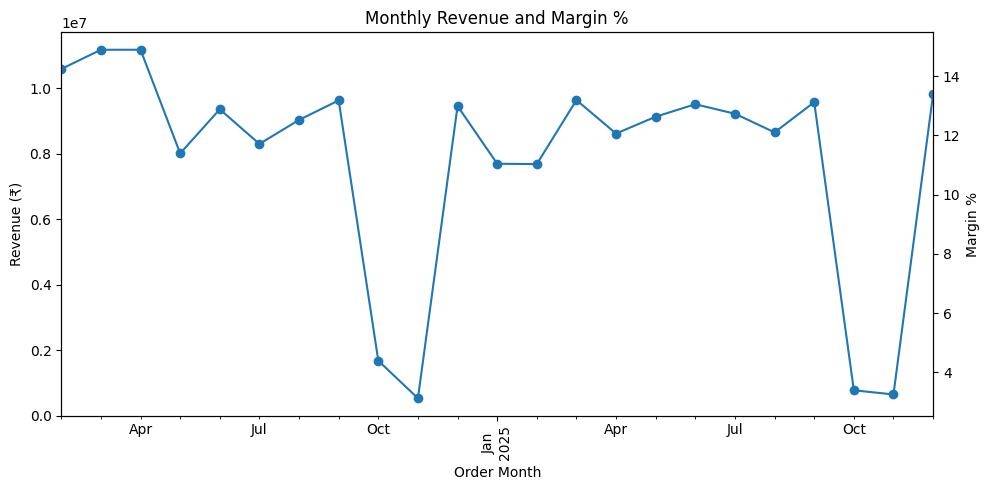

In [ ]:
# Visualization: monthly revenue and margin %
fig, ax1 = plt.subplots(figsize=(10, 5))
monthly["revenue"].plot(kind="bar", ax=ax1)
ax1.set_title("Monthly Revenue and Margin %")
ax1.set_xlabel("Order Month")
ax1.set_ylabel("Revenue (₹)")
ax2 = ax1.twinx()
monthly["margin_pct"].plot(ax=ax2, marker="o")
ax2.set_ylabel("Margin %")
plt.tight_layout()
plt.show()

Q.6 Weekday vs Weekend behaviour

In [ ]:
master.groupby("is_weekend")["revenue"].sum()

is_weekend
False    68020587.42
True     33481181.76
Name: revenue, dtype: float64

In [ ]:
master.groupby("is_weekend")["order_id"].nunique()

is_weekend
False    15385
True      7621
Name: order_id, dtype: int64

In [ ]:
#revenue per order
weekend_aov = (master.groupby("is_weekend")["revenue"].sum()
/ master.groupby("is_weekend")["order_id"].nunique())

In [ ]:
weekend_aov.round(2)

is_weekend
False    4421.23
True     4393.28
dtype: float64

In [ ]:
master.groupby("is_weekend")["margin"].sum().round(2)

is_weekend
False    6680547.41
True     3375014.93
Name: margin, dtype: float64

In [ ]:
weekend_margin_pct = (
    master.groupby("is_weekend")["margin"].sum()
    / master.groupby("is_weekend")["revenue"].sum()
) * 100

In [ ]:
weekend_margin_pct.round(2)

is_weekend
False     9.82
True     10.08
dtype: float64

### Business interpretation

Compare weekend and weekday behaviour using both AOV and margin %. This helps distinguish higher order activity from genuinely better economics.

# Phase 3 — The Profitability Deep Dive (the core)

1. City P&L — which city loses money?

In [ ]:
city_analysis = master.groupby("city")[["revenue", "margin"]].sum()

In [ ]:
city_analysis

,revenue,margin
city,,
Bengaluru,21298565.75,3372799.06
Chennai,7923340.52,38432.49
Delhi,27386454.79,2196839.96
Hyderabad,9506078.89,-558843.08
Mumbai,24934165.79,4618180.40
Pune,10453163.44,388153.51


In [ ]:
city_analysis["gm_pct"] = (
    city_analysis["margin"]
    / city_analysis["revenue"]
    )                    #gross margin

In [ ]:
city_analysis.round(2)

,revenue,margin,gm_pct
city,,,
Bengaluru,21298565.75,3372799.06,0.16
Chennai,7923340.52,38432.49,0.00
Delhi,27386454.79,2196839.96,0.08
Hyderabad,9506078.89,-558843.08,-0.06
Mumbai,24934165.79,4618180.40,0.19
Pune,10453163.44,388153.51,0.04


In [ ]:
city_orders = master.groupby("city")["order_id"].nunique()
city_analysis["aov"] = city_analysis["revenue"] / city_orders

In [ ]:
city_analysis.round(2)

,revenue,margin,gm_pct,aov
city,,,,
Bengaluru,21298565.75,3372799.06,0.16,4774.39
Chennai,7923340.52,38432.49,0.00,4024.04
Delhi,27386454.79,2196839.96,0.08,4280.47
Hyderabad,9506078.89,-558843.08,-0.06,3741.08
Mumbai,24934165.79,4618180.40,0.19,4863.31
Pune,10453163.44,388153.51,0.04,4164.61


In [ ]:
city_delivery = master.groupby("city")["delivery_minutes"].mean()

In [ ]:
city_delivery.round(1)

city
Bengaluru    24.8
Chennai      23.4
Delhi        19.5
Hyderabad    28.6
Mumbai       22.5
Pune         20.6
Name: delivery_minutes, dtype: float64

### Business recommendation

Prioritise cities with negative or weak margin for deeper diagnosis. Compare their AOV and delivery performance with stronger cities before deciding whether the problem is pricing, basket size, operations, or product mix.

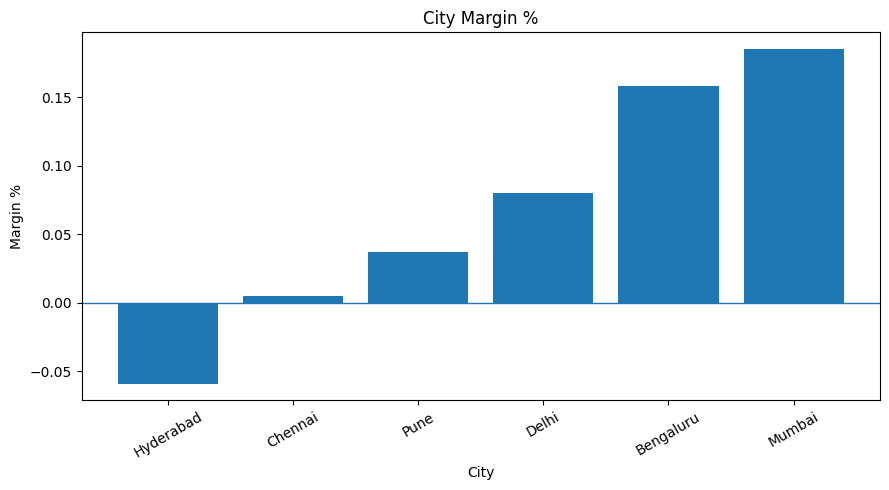

In [ ]:
# Visualization: city margin %
city_plot = city_analysis.sort_values("gm_pct")
plt.figure(figsize=(9, 5))
plt.bar(city_plot.index, city_plot["gm_pct"])
plt.axhline(0, linewidth=1)
plt.title("City Margin %")
plt.xlabel("City")
plt.ylabel("Margin %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

2. Discount Analysis

In [ ]:
master["discount_pct"].value_counts().sort_index()
#to see what discount percentages actually exist in the data

discount_pct
0     12957
5     16089
10    14982
15    14234
20    11889
25     6039
30     6793
35     3756
40     3482
45     2245
50     1235
Name: count, dtype: int64

In [ ]:
#create the bands
band = pd.cut(
    master["discount_pct"],
    bins = [-1, 0, 10, 20, 30, 60],
    labels = ["0%", "1-10%", "11-20%", "21-30%", ">30%"]

)

In [ ]:
pd.DataFrame({
    "discount_pct": master["discount_pct"].head(20),
    "band": band.head(20)
})

,discount_pct,band
0,25,21-30%
1,25,21-30%
2,25,21-30%
3,25,21-30%
4,25,21-30%
5,15,11-20%
6,15,11-20%
7,15,11-20%
8,15,11-20%
9,0,0%


In [ ]:
#total revenue for each discount band
discount_revenue = master.groupby(band, observed=True)["revenue"].sum()

In [ ]:
discount_revenue

discount_pct
0%        16701986.18
1-10%     36730759.81
11-20%    27906140.65
21-30%    12048078.31
>30%       8114804.23
Name: revenue, dtype: float64

In [ ]:
#At what discount level does an order stop making money?
discount_margin = master.groupby(band, observed= True)["margin"].sum()

In [ ]:
discount_margin

discount_pct
0%        4069152.87
1-10%     6555490.68
11-20%    2270336.07
21-30%    -585828.52
>30%     -2253588.76
Name: margin, dtype: float64

In [ ]:
discount_gm_pct = (discount_margin / discount_revenue)*100

In [ ]:
discount_gm_pct.round(2)

discount_pct
0%        24.36
1-10%     17.85
11-20%     8.14
21-30%    -4.86
>30%     -27.77
dtype: float64

In [ ]:
#"How much of our business is actually exposed to each discount level?"
discount_revenue_share = (
    discount_revenue / discount_revenue.sum()
) * 100

In [ ]:
discount_revenue_share

discount_pct
0%        16.454872
1-10%     36.187310
11-20%    27.493255
21-30%    11.869821
>30%       7.994742
Name: revenue, dtype: float64

### Business recommendation

Treat the discount threshold as a pricing-control issue. If margin becomes negative above a particular discount range, management should test lower or more targeted discounts rather than relying on broad discounting.

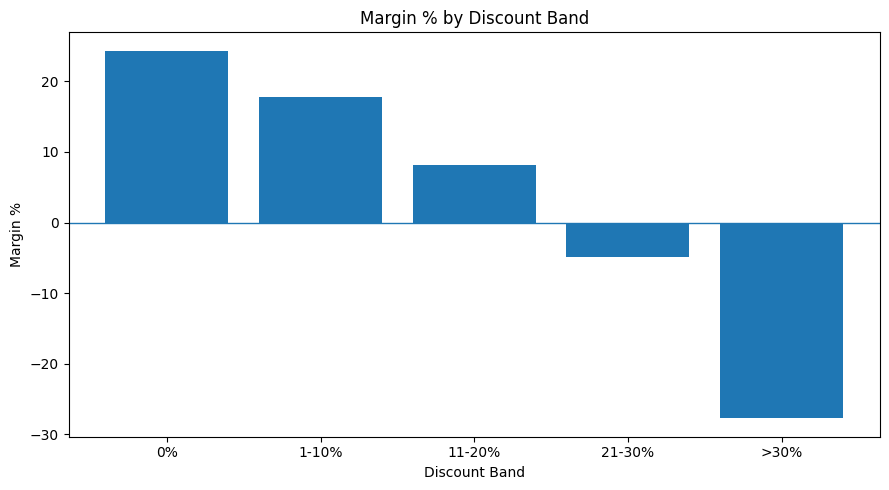

In [ ]:
# Visualization: discount band vs margin %
plt.figure(figsize=(9, 5))
plt.bar(discount_gm_pct.index.astype(str), discount_gm_pct.values)
plt.axhline(0, linewidth=1)
plt.title("Margin % by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Margin %")
plt.tight_layout()
plt.show()

3. Category Margin(
Which category is dragging down margin?)

In [ ]:
category_analysis = master.groupby("category")[["revenue","margin"]].sum()

In [ ]:
category_analysis

,revenue,margin
category,,
Baby Care,17533896.95,2802188.12
Dairy & Bakery,4841936.10,175215.08
Fruits & Vegetables,1069923.48,82530.25
Household,15838094.37,3367397.62
Personal Care,12663958.08,3615177.47
Snacks & Beverages,4183998.68,784972.04
Staples,45369961.52,-771918.24


In [ ]:
category_analysis["gm_pct"] = (
    category_analysis["margin"]
    / category_analysis["revenue"]
) * 100

In [ ]:
category_analysis.round(2)

,revenue,margin,gm_pct
category,,,
Baby Care,17533896.95,2802188.12,15.98
Dairy & Bakery,4841936.10,175215.08,3.62
Fruits & Vegetables,1069923.48,82530.25,7.71
Household,15838094.37,3367397.62,21.26
Personal Care,12663958.08,3615177.47,28.55
Snacks & Beverages,4183998.68,784972.04,18.76
Staples,45369961.52,-771918.24,-1.70


### Business recommendation

Do not evaluate categories only by revenue share. Review large categories with weak or negative margin, and use higher-margin categories to improve basket economics through cross-selling and assortment decisions.

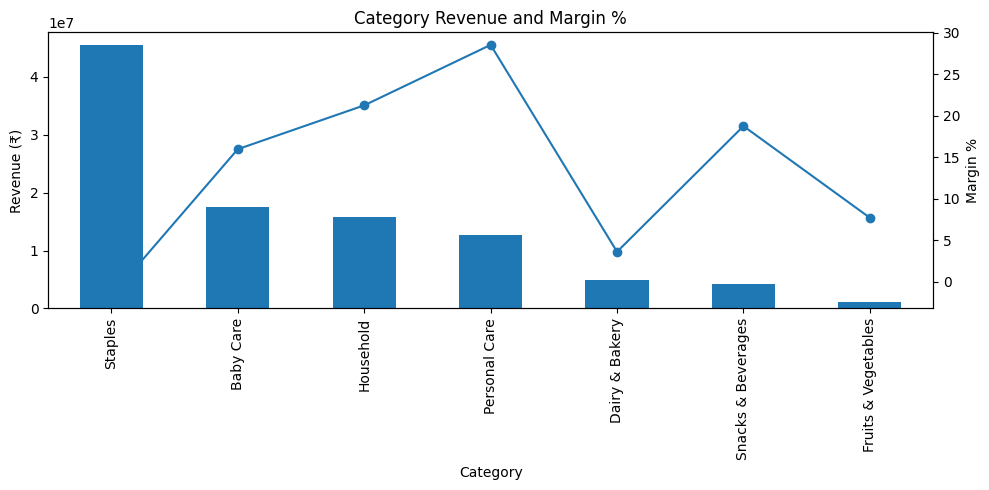

In [ ]:
# Visualization: category revenue and margin %
category_plot = category_analysis.sort_values("revenue", ascending=False)
fig, ax1 = plt.subplots(figsize=(10, 5))
category_plot["revenue"].plot(kind="bar", ax=ax1)
ax1.set_title("Category Revenue and Margin %")
ax1.set_xlabel("Category")
ax1.set_ylabel("Revenue (₹)")
ax2 = ax1.twinx()
category_plot["gm_pct"].plot(ax=ax2, marker="o")
ax2.set_ylabel("Margin %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Pareto — 80% of margin from how many products?


In [ ]:
product_margin = master.groupby("product_id")["margin"].sum()
product_margin.head()

product_id
P5001    1862.65
P5002    8056.91
P5003    2304.33
P5004    3174.21
P5005    1793.81
Name: margin, dtype: float64

In [ ]:
#Sort products from highest margin to lowest margin.
product_margin = product_margin.sort_values(ascending=False)

In [ ]:
product_margin.head(10)

product_id
P5090    1774209.41
P5103    1576228.81
P5135    1071861.31
P5125     701786.55
P5097     555356.70
P5098     393967.89
P5131     376733.44
P5111     348360.17
P5091     258016.66
P5120     257413.25
Name: margin, dtype: float64

In [ ]:
#Calculate cumulative margin
cumulative_margin = product_margin.cumsum()
cumulative_margin.head(10)

product_id
P5090    1774209.41
P5103    3350438.22
P5135    4422299.53
P5125    5124086.08
P5097    5679442.78
P5098    6073410.67
P5131    6450144.11
P5111    6798504.28
P5091    7056520.94
P5120    7313934.19
Name: margin, dtype: float64

In [ ]:
#calculate cumulative margin %
cumulative_margin_pct = (
    cumulative_margin / product_margin.sum()
) * 100
cumulative_margin_pct.head(10)

product_id
P5090    17.644060
P5103    33.319253
P5135    43.978640
P5125    50.957728
P5097    56.480608
P5098    60.398518
P5131    64.145036
P5111    67.609389
P5091    70.175299
P5120    72.735208
Name: margin, dtype: float64

In [ ]:
#find the actual product names
top_products = master[
    master["product_id"].isin(
        product_margin.head(3).index
    )
][["product_id", "product_name", "category"]].drop_duplicates()

In [ ]:
top_products

,product_id,product_name,category
2,P5135,Parle Baby Food Pack 3,Baby Care
3,P5103,Mother Dairy Cleaning Pack 1,Household
25,P5090,Himalaya Skin Care Pack 5,Personal Care


### Business recommendation

Use the product ranking to identify high-contribution products that deserve inventory availability and promotion attention. The analysis should support prioritisation rather than simply listing product IDs.

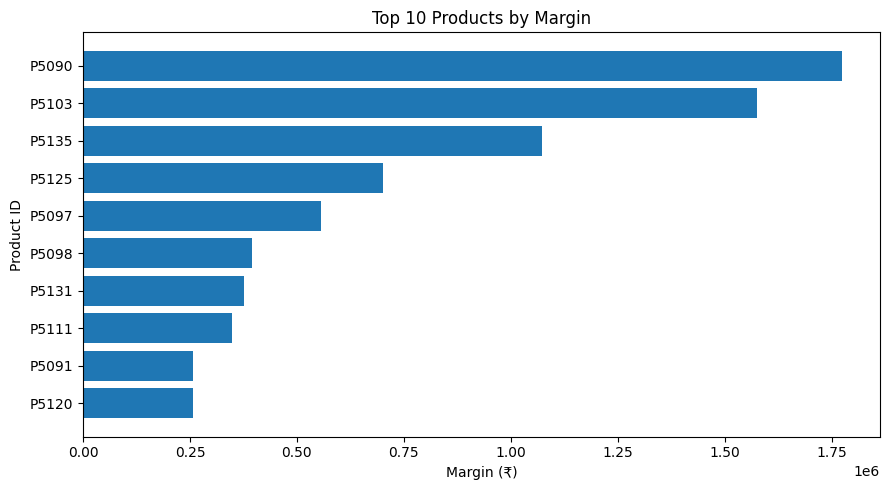

In [ ]:
# Visualization: top 10 products by margin
top10_margin = product_margin.head(10).sort_values()
plt.figure(figsize=(9, 5))
plt.barh(top10_margin.index.astype(str), top10_margin.values)
plt.title("Top 10 Products by Margin")
plt.xlabel("Margin (₹)")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()

Q. Delivery Time vs Customer Rating
(Are slower deliveries associated with lower customer ratings?)

In [ ]:
master[["delivery_minutes","delivery_rating"]].corr()
#There is a strong negative association between delivery time and customer rating.

,delivery_minutes,delivery_rating
delivery_minutes,1.000000,-0.750385
delivery_rating,-0.750385,1.000000


### Business interpretation

A negative correlation means longer delivery times tend to be associated with lower ratings in this dataset. Correlation shows association, not proof of causation. Operational decisions should therefore combine this result with delivery-volume and service-level analysis.

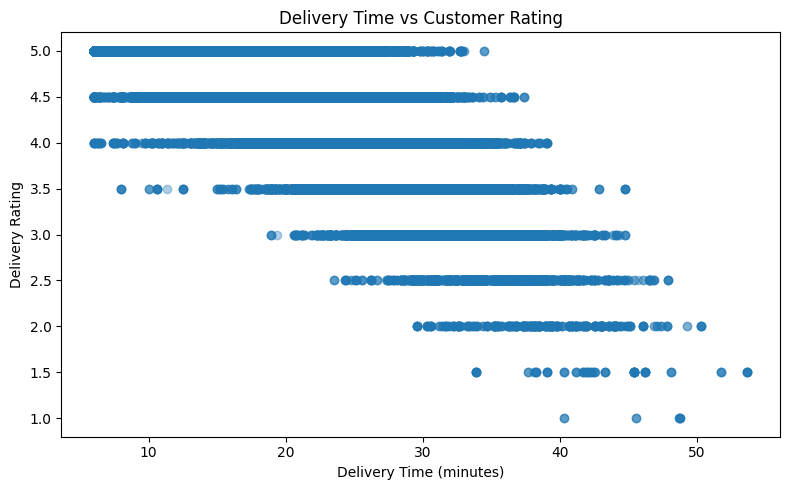

In [ ]:
# Visualization: delivery time vs rating
delivery_plot = master[["delivery_minutes", "delivery_rating"]].dropna()
plt.figure(figsize=(8, 5))
plt.scatter(delivery_plot["delivery_minutes"], delivery_plot["delivery_rating"], alpha=0.35)
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Delivery Rating")
plt.tight_layout()
plt.show()

# Phase 4 — Customer Analytics: RFM (optional extension)

RFM is kept as an optional extension to the core profitability project.

Step 1 — Find each customer's most recent order

In [ ]:
customer_last_order = master.groupby("customer_id")["order_date"].max()

In [ ]:
customer_last_order.head()

customer_id
C100000   2025-11-20
C100001   2025-07-07
C100003   2025-11-28
C100005   2025-11-14
C100006   2025-12-10
Name: order_date, dtype: datetime64[ns]

In [ ]:
master["order_date"].max()

Timestamp('2025-12-30 00:00:00')

In [ ]:
recency = master["order_date"].max() - customer_last_order

In [ ]:
#Convert Timedelta to days
recency = recency.dt.days
recency.head()

customer_id
C100000     40
C100001    176
C100003     32
C100005     46
C100006     20
Name: order_date, dtype: int64

Step 2 How often does each customer order?

In [ ]:
frequency = master.groupby("customer_id")["order_id"].nunique()

In [ ]:
frequency.head()

customer_id
C100000     2
C100001     1
C100003    13
C100005     8
C100006     2
Name: order_id, dtype: int64

Step 3 — Calculate Monetary

In [ ]:
monetary = master.groupby("customer_id")["revenue"].sum()

Create the RFM table (recency , frequency, monetary)

In [ ]:
rfm = pd.concat([recency, frequency, monetary], axis = 1)

In [ ]:
rfm.head()

,order_date,order_id,revenue
customer_id,,,
C100000,40,2,8707.68
C100001,176,1,1245.12
C100003,32,13,65955.54
C100005,46,8,38758.17
C100006,20,2,5257.25


In [ ]:
rfm.columns = ["recency", "frequency", "monetary"]
rfm.head()

,recency,frequency,monetary
customer_id,,,
C100000,40,2,8707.68
C100001,176,1,1245.12
C100003,32,13,65955.54
C100005,46,8,38758.17
C100006,20,2,5257.25


In [ ]:
import pandas as pd

In [ ]:
rfm["frequency"].value_counts().sort_index()
#How many customers have each particular number of orders

frequency
1     990
2     796
3     600
4     473
5     366
6     292
7     209
8     226
9     145
10    104
11     87
12     64
13     59
14     46
15     56
16     26
17     28
18     24
19     17
20     14
21      9
22     15
23      4
24      2
25      2
26      2
27      7
28      3
29      5
30      1
31      3
32      3
33      2
38      1
42      2
45      1
Name: count, dtype: int64

In [ ]:
#What frequency value marks approximately 0%, 20%, 40%, 60%, 80%, and 100% of the customers?
rfm["frequency"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

0.0     1.0
0.2     1.0
0.4     3.0
0.6     4.0
0.8     8.0
1.0    45.0
Name: frequency, dtype: float64

In [ ]:
#Create the F score
rfm["F"] = pd.cut(
    rfm["frequency"],
    bins=[0, 2, 5, 10, 20, 100],
    labels=[1, 2, 3, 4, 5]
)

In [ ]:
rfm[["frequency", "F"]].head(10)

,frequency,F
customer_id,,
C100000,2,1
C100001,1,1
C100003,13,4
C100005,8,3
C100006,2,1
C100008,4,2
C100011,20,4
C100012,3,2
C100014,7,3


In [ ]:
#Create the R score
rfm["R"] = pd.cut(
    rfm["recency"],
    bins = [-1, 30, 60, 90, 180, 1000],
    labels =[5, 4, 3, 2, 1]
)

In [ ]:
rfm[["recency", "R"]].head(10)

,recency,R
customer_id,,
C100000,40,4
C100001,176,2
C100003,32,4
C100005,46,4
C100006,20,5
C100008,63,3
C100011,31,4
C100012,31,4
C100014,67,3


In [ ]:
#monetary value into an M score from 1 to 5
#range of customer spending.
rfm["monetary"].describe()


count      4684.000000
mean      21669.890944
std       21359.183788
min          83.860000
25%        7118.147500
50%       15010.830000
75%       28983.592500
max      251506.930000
Name: monetary, dtype: float64

In [ ]:
rfm["monetary"].quantile([0.8, 0.9, 0.95, 0.99, 1])

0.80     33624.2400
0.90     49235.5430
0.95     63350.1990
0.99     98810.1036
1.00    251506.9300
Name: monetary, dtype: float64

In [ ]:
rfm["M"] = pd.qcut(
    rfm["monetary"].rank (method ="first"), 5,
    labels = [1,2,3,4,5]
)

In [ ]:
rfm[["monetary", "M"]].head(10)

,monetary,M
customer_id,,
C100000,8707.68,2
C100001,1245.12,1
C100003,65955.54,5
C100005,38758.17,5
C100006,5257.25,1
C100008,22468.85,4
C100011,89100.42,5
C100012,10980.15,2
C100014,23112.90,4


In [ ]:
rfm[["recency", "R", "frequency", "F", "monetary", "M"]].head(10)

,recency,R,frequency,F,monetary,M
customer_id,,,,,,
C100000,40,4,2,1,8707.68,2
C100001,176,2,1,1,1245.12,1
C100003,32,4,13,4,65955.54,5
C100005,46,4,8,3,38758.17,5
C100006,20,5,2,1,5257.25,1
C100008,63,3,4,2,22468.85,4
C100011,31,4,20,4,89100.42,5
C100012,31,4,3,2,10980.15,2
C100014,67,3,7,3,23112.90,4


combine R, F and M

In [ ]:
rfm["RFM_score"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

In [ ]:
rfm[["R", "F", "M", "RFM_score"]].head(10)

,R,F,M,RFM_score
customer_id,,,,
C100000,4,1,2,412
C100001,2,1,1,211
C100003,4,4,5,445
C100005,4,3,5,435
C100006,5,1,1,511
C100008,3,2,4,324
C100011,4,4,5,445
C100012,4,2,2,422
C100014,3,3,4,334


In [ ]:
import numpy as np

Step 5 Customer Segmentation

In [ ]:
conditions = [
    (rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4),

    (rfm["R"] >= 3) & (rfm["F"] >= 3),

    (rfm["R"] <= 2) & (
        (rfm["F"] >= 3) | (rfm["M"] >= 3)
    ),

    (rfm["R"] <= 2) & (rfm["F"] <= 2) & (rfm["M"] <= 2)
]

choices = [
    "Champions",
    "Loyal Customers",
    "At Risk",
    "Lost"
]

rfm["segment"] = np.select(
    conditions,
    choices,
    default="Other"
)


In [ ]:
rfm[["R", "F", "M", "RFM_score", "segment"]].head(20)

,R,F,M,RFM_score,segment
customer_id,,,,,
C100000,4,1,2,412,Lost
C100001,2,1,1,211,Lost
C100003,4,4,5,445,Champions
C100005,4,3,5,435,At Risk
C100006,5,1,1,511,Lost
C100008,3,2,4,324,At Risk
C100011,4,4,5,445,Champions
C100012,4,2,2,422,Lost
C100014,3,3,4,334,Loyal Customers


In [ ]:
rfm["segment"].value_counts()

segment
At Risk            1878
Lost               1436
Other               643
Loyal Customers     436
Champions           291
Name: count, dtype: int64

## Executive Summary

### What the analysis tells us

- The project first establishes a reliable transaction base through duplicate checks, text standardisation, date parsing, missing-value decisions, and invalid-value handling.
- Overall sales performance should be judged using revenue, order volume, AOV, gross margin, and margin %.
- City analysis identifies where revenue is concentrated and which locations have weak or negative profitability.
- Discount-band analysis tests whether deeper discounting is associated with negative margin and quantifies the revenue exposed to each band.
- Category and product analysis separates sales-driving areas from profit-driving areas.
- Delivery-time analysis examines the relationship between operational speed and customer ratings.

### Business recommendations

1. **Review high-discount transactions:** establish a controlled discount threshold and test targeted promotions rather than broad discounting when margins become negative.
2. **Investigate loss-making cities:** compare delivery time, AOV, and product mix before deciding whether the response should be operational improvement, basket-building, or footprint optimisation.
3. **Protect profitable assortment:** maintain availability of high-margin/high-contribution products and use cross-selling to improve basket economics.
4. **Improve delivery performance:** monitor service levels because longer delivery times are associated with lower customer ratings in this dataset.

> **Note:** The RFM section above is an optional extension. It is useful for demonstrating customer segmentation, but it is not required to understand the core profitability story.

## Portfolio Note

This project uses a **simulated/synthetic QuickBasket dataset** designed for analytics practice. The notebook demonstrates a complete entry-level analyst workflow: clean the data, validate assumptions, calculate business metrics, compare performance, visualise findings, and conclude with management recommendations.

